# The same release, as a noisy value

This is [`opendp_basics.ipynb`](opendp_basics.ipynb)'s volunteer-hours release
again, but built with `noisyvalue.opendp` instead of raw OpenDP. The
measurement itself is unchanged — same transformation, same Gaussian
mechanism, same privacy guarantee — only the *wrapping* differs: instead of a
bare float, the release comes back as a `NoisyFloat` whose posterior travels
with it through everything computed downstream.

In [1]:
import numpy as np

import opendp.prelude as dp

dp.enable_features("contrib", "honest-but-curious")

from noisyvalue import opendp as nvdp
from noisyvalue import plot_posterior, sample_noisy_values

## The data

Identical to the baseline notebook: twenty volunteers, hours bounded to
[0, 10].

In [2]:
hours = [2.5, 6.0, 0.0, 10.0, 4.5, 7.5, 3.0, 8.0, 1.0, 9.5,
        5.0, 6.5, 2.0, 10.0, 0.5, 7.0, 3.5, 9.0, 4.0, 8.5]
true_sum = sum(hours)
true_sum

108.0

## Build the release

`nvdp.make_gaussian` is a drop-in replacement for `dp.m.make_gaussian`: it
builds the identical vetted OpenDP measurement internally and only changes
what comes back. The transformation, the chaining (`>>`), and the privacy
map are all exactly as before — `meas.map(1)` reports the same rho as the
plain-OpenDP version.

In [3]:
trans = dp.t.make_sum(
    dp.vector_domain(dp.atom_domain(bounds=(0.0, 10.0), nan=False)),
    dp.symmetric_distance())

scale = 10.0
meas = trans >> nvdp.make_gaussian(trans.output_domain, trans.output_metric, scale)

print(f"privacy loss (rho): {meas.map(1):.4f}")

privacy loss (rho): 0.5000


In [4]:
value = meas(hours)
print(f"true total: {true_sum}")
print(f"released:   {value}  ({type(value).__name__})")

true total: 108.0
released:   ~107.42350390589763  (NoisyFloat)


## The release already knows its own uncertainty

`value` is a `NoisyFloat`: the released number, paired with the posterior of
the true total under a flat prior — a Normal density centered on the release
with the mechanism's scale, exactly the law `opendp_basics.ipynb` had to
carry around separately as `scale`. `plot_posterior` renders it directly, by
quadrature rather than simulation:

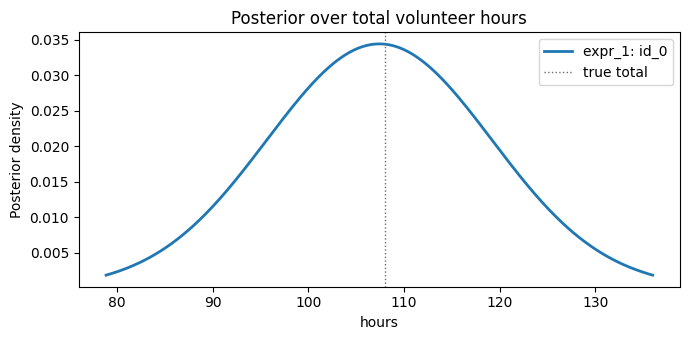

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_posterior(value, ax=ax)
ax.axvline(true_sum, color="#6b6b6b", linewidth=1, linestyle=":", label="true total")
ax.legend()
ax.set_title("Posterior over total volunteer hours")
ax.set_xlabel("hours")
plt.tight_layout()

Sampling it gives the same 95% interval the baseline notebook had to
derive by hand from `scipy.stats.norm` — here it falls out of `.sample()`:

In [6]:
draws = value.sample(n=8000, rng=np.random.default_rng(0)).draws
lo, hi = np.percentile(draws, [2.5, 97.5])
print(f"released total: {float(value):.2f}")
print(f"95% interval:    [{lo:.2f}, {hi:.2f}]")

released total: 107.42
95% interval:    [87.95, 127.09]


## Uncertainty survives further computation

Average hours per volunteer is `value` divided by the (public) volunteer
count — ordinary `NoisyFloat` arithmetic, so the posterior comes along for
free instead of needing a second by-hand derivation:

In [7]:
avg = value / len(hours)
avg_draws = avg.sample(n=8000, rng=np.random.default_rng(0)).draws
avg_lo, avg_hi = np.percentile(avg_draws, [2.5, 97.5])
print(f"released average: {float(avg):.3f}")
print(f"95% interval:      [{avg_lo:.3f}, {avg_hi:.3f}]")

released average: 5.371
95% interval:      [4.397, 6.355]


## Combining repeated releases

Spending more budget to measure the same statistic twice should make the
combined estimate more precise, not just give two disconnected numbers. A
`SharedLatentRegistry` gives the total a stable identity across releases:
both measurements are folded into one posterior in closed form, and *every*
value already issued for that key — including `first`, released before the
second measurement happened — tightens in place.

In [8]:
registry = nvdp.SharedLatentRegistry()
meas_shared = trans >> nvdp.make_gaussian(
    trans.output_domain, trans.output_metric, scale,
    key="total_hours", registry=registry)

first = meas_shared(hours)
print(f"after one release:  center={registry.posterior('total_hours')[0]:.2f}, "
     f"variance={registry.posterior('total_hours')[1]:.2f}")

second = meas_shared(hours)
print(f"after two releases: center={registry.posterior('total_hours')[0]:.2f}, "
     f"variance={registry.posterior('total_hours')[1]:.2f}")

after one release:  center=107.03, variance=100.00
after two releases: center=106.33, variance=50.00


`first` and `second` are two different observed numbers, but they're
views of one random variable — the joint sampler draws them perfectly
correlated, and `first`'s posterior reflects both releases even though it
was issued before the second one happened:

first release observed:  107.03
second release observed: 105.63
draws identical:         True


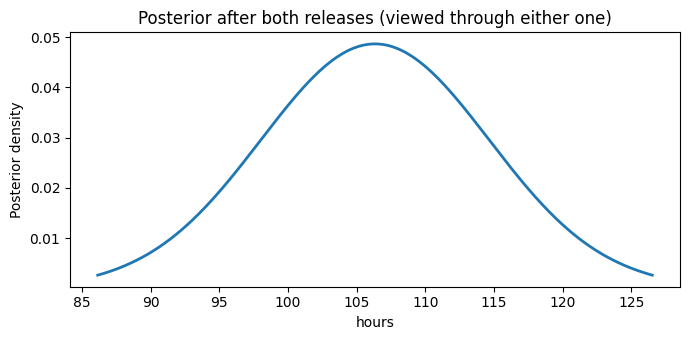

In [9]:
a, b = sample_noisy_values(first, second, n=2000, rng=np.random.default_rng(0))
print(f"first release observed:  {float(first):.2f}")
print(f"second release observed: {float(second):.2f}")
print(f"draws identical:         {np.array_equal(a.draws, b.draws)}")

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_posterior(first, ax=ax)
ax.set_title("Posterior after both releases (viewed through either one)")
ax.set_xlabel("hours")
plt.tight_layout()

This registry-based combination works for repeat measurements of
*one* statistic. See [`opendp_polars.ipynb`](opendp_polars.ipynb) for
the related case of a `dp.Context` releasing a whole table at once,
and for combining independent releases of the *same* aggregate made
at different levels of granularity (`release_query` and `link_sum`).